# Pricing Options: From Black–Scholes to Monte Carlo
## Step 5 — Monte Carlo Pricing of a European Option

**Target audience:** second-year undergraduate students  
**Goal of this notebook:** understand how Monte Carlo simulation can be used to price a European option and how the numerical estimate connects to the Black–Scholes formula.

---

## Learning objectives

At the end of this notebook, the student should be able to:

- explain the idea of Monte Carlo pricing,
- simulate terminal stock prices under the Black–Scholes model,
- compute the payoff of a European call and a European put,
- discount simulated payoffs to estimate the option price,
- compare the Monte Carlo estimate with the Black–Scholes formula,
- understand why the Monte Carlo estimator is random,
- explain why increasing the number of simulations improves accuracy.


## 1. Why do we need Monte Carlo methods?

For a European call and put under Black–Scholes, we already have a closed-form formula.
So why use simulation at all?

Because many derivatives are much more complicated:

- path-dependent options,
- basket options,
- barrier options,
- options in more advanced models.

For such products, a closed-form formula may not exist.
In those situations, Monte Carlo simulation becomes a very powerful numerical tool.

The European option is therefore the perfect first example:

- simple enough to understand,
- but rich enough to illustrate the full simulation idea.


## 2. General principle of Monte Carlo pricing

The Black–Scholes framework tells us that the value of a European option today is the discounted expected value of its payoff under the risk-neutral model.

For a European call,

$$
C_0 = e^{-rT} \mathbb{E}\left[(S_T-K)^+\right].
$$

For a European put,

$$
P_0 = e^{-rT} \mathbb{E}\left[(K-S_T)^+\right].
$$

The Monte Carlo idea is simple:

1. simulate many possible values of $S_T$,
2. compute the payoff for each simulated path,
3. average these payoffs,
4. discount the average back to time 0.

This gives a numerical approximation of the option price.


## 3. Risk-neutral terminal stock price

Under the risk-neutral Black–Scholes model, the terminal stock price is

$$
S_T = S_0 \exp\left(\left(r - \frac{1}{2}\sigma^2\right)T + \sigma \sqrt{T} Z\right),
$$

where

$$
Z \sim \mathcal{N}(0,1).
$$

Notice the important change compared with the real-world model:

- the drift is now **$r$**, not $\mu$.

This is because pricing is done under the **risk-neutral measure**.


## 4. Monte Carlo algorithm for a European call

To price a European call, we proceed as follows:

1. Generate independent standard normal random variables $Z_1, Z_2, \dots, Z_N$.
2. Compute simulated terminal prices

   $$
   S_T^{(i)} = S_0 \exp\left(\left(r - \frac{1}{2}\sigma^2\right)T + \sigma \sqrt{T} Z_i\right).
   $$

3. Compute the simulated payoff of each path:

   $$
   X_i = \max(S_T^{(i)} - K, 0).
   $$

4. Average the payoffs:

   $$
   \bar{X}_N = \frac{1}{N} \sum_{i=1}^N X_i.
   $$

5. Discount to obtain the Monte Carlo estimator:

   $$
   \hat{C}_N = e^{-rT} \bar{X}_N.
   $$

This estimator is random because it depends on simulated random numbers.


## 5. First implementation in Python

We now implement the Monte Carlo estimator and compare it with the exact Black–Scholes price.


In [1]:
import math
import numpy as np
from math import log, sqrt, exp, erf

# Standard normal CDF

def Phi(x):
    return 0.5 * (1.0 + erf(x / math.sqrt(2.0)))


def bs_call_price(S0, K, T, r, sigma):
    d1 = (log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * sqrt(T))
    d2 = d1 - sigma * sqrt(T)
    return S0 * Phi(d1) - K * exp(-r * T) * Phi(d2)


def bs_put_price(S0, K, T, r, sigma):
    d1 = (log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * sqrt(T))
    d2 = d1 - sigma * sqrt(T)
    return K * exp(-r * T) * Phi(-d2) - S0 * Phi(-d1)


def mc_call_price(S0, K, T, r, sigma, N, seed=None):
    if seed is not None:
        np.random.seed(seed)
    Z = np.random.randn(N)
    ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    payoffs = np.maximum(ST - K, 0)
    return np.exp(-r * T) * np.mean(payoffs)


def mc_put_price(S0, K, T, r, sigma, N, seed=None):
    if seed is not None:
        np.random.seed(seed)
    Z = np.random.randn(N)
    ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    payoffs = np.maximum(K - ST, 0)
    return np.exp(-r * T) * np.mean(payoffs)

S0 = 100
K = 100
T = 1.0
r = 0.05
sigma = 0.20
N = 100_000

mc_call = mc_call_price(S0, K, T, r, sigma, N, seed=123)
mc_put = mc_put_price(S0, K, T, r, sigma, N, seed=123)
bs_call = bs_call_price(S0, K, T, r, sigma)
bs_put = bs_put_price(S0, K, T, r, sigma)

print(f"Monte Carlo call price : {mc_call:.4f}")
print(f"Black–Scholes call    : {bs_call:.4f}")
print()
print(f"Monte Carlo put price : {mc_put:.4f}")
print(f"Black–Scholes put     : {bs_put:.4f}")


Monte Carlo call price : 10.4715
Black–Scholes call    : 10.4506

Monte Carlo put price : 5.5694
Black–Scholes put     : 5.5735


### Interpretation

The Monte Carlo prices are close to the Black–Scholes values, but not exactly equal.
This difference is normal: Monte Carlo uses a finite number of simulations, so the estimate contains statistical error.


## 6. Why is the Monte Carlo estimate random?

Each time we run the simulation, we generate different random variables.
Therefore, the estimated option price changes slightly from run to run.

This means that the Monte Carlo estimator is itself a random variable.

If the number of simulations $N$ is large, the estimator becomes more stable.
This is a consequence of the **law of large numbers**.


In [2]:
S0 = 100
K = 100
T = 1.0
r = 0.05
sigma = 0.20
N = 20_000

estimates = []
for seed in range(10):
    estimates.append(mc_call_price(S0, K, T, r, sigma, N, seed=seed))

print("Ten Monte Carlo estimates of the same call price:")
for i, est in enumerate(estimates, start=1):
    print(f"Run {i:2d}: {est:.4f}")


Ten Monte Carlo estimates of the same call price:
Run  1: 10.2945
Run  2: 10.5757
Run  3: 10.4785
Run  4: 10.2576
Run  5: 10.4003
Run  6: 10.5164
Run  7: 10.3819
Run  8: 10.2294
Run  9: 10.4441
Run 10: 10.4135


### Interpretation

Even though all runs are pricing the same option, the numerical estimates are not identical.
This variability is a normal feature of Monte Carlo simulation.


## 7. Visualizing simulated terminal prices and payoffs

Monte Carlo works by simulating many possible final stock prices.
It is useful to visualize both:

- the distribution of simulated terminal prices,
- the distribution of simulated payoffs.


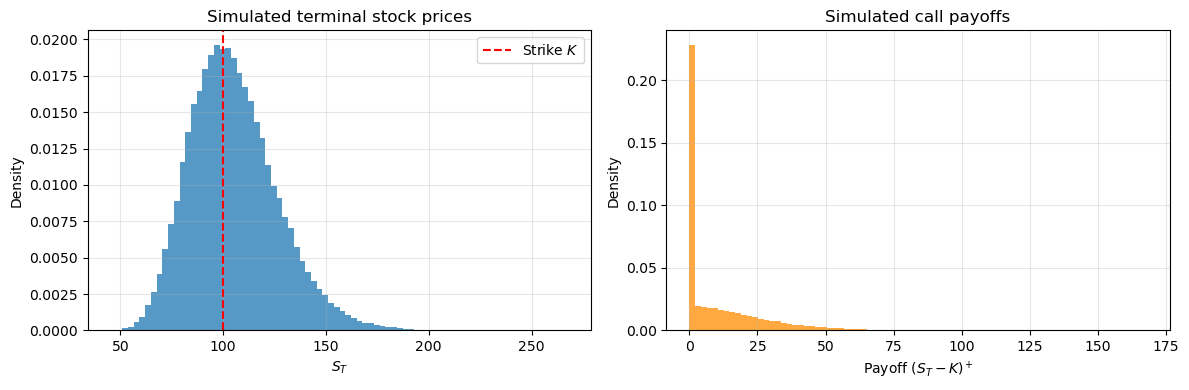

In [3]:
import matplotlib.pyplot as plt

np.random.seed(2024)
N = 100_000
Z = np.random.randn(N)
ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
call_payoffs = np.maximum(ST - K, 0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(ST, bins=80, density=True, alpha=0.75)
axes[0].axvline(K, linestyle='--', color='red', label='Strike $K$')
axes[0].set_title('Simulated terminal stock prices')
axes[0].set_xlabel('$S_T$')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(call_payoffs, bins=80, density=True, alpha=0.75, color='darkorange')
axes[1].set_title('Simulated call payoffs')
axes[1].set_xlabel('Payoff $(S_T-K)^+$')
axes[1].set_ylabel('Density')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Interpretation

- The terminal stock prices have a right-skewed shape, consistent with a lognormal distribution.
- The call payoff distribution has a large mass near zero, because many simulated paths finish below the strike and produce zero payoff.
- Large positive payoffs are possible, but less frequent.

This explains why option payoff distributions are often skewed.


## 8. Convergence as the number of simulations increases

A key question is:

> How does the Monte Carlo estimate behave when the number of simulations increases?

The answer is that the estimate converges toward the true price.

We can observe this numerically by computing the estimate for several values of $N$.


In [4]:
sample_sizes = [100, 300, 1000, 3000, 10000, 30000, 100000, 300000]
mc_estimates = [mc_call_price(S0, K, T, r, sigma, N, seed=42) for N in sample_sizes]
bs_exact = bs_call_price(S0, K, T, r, sigma)

for N, est in zip(sample_sizes, mc_estimates):
    print(f"N = {N:6d}   Monte Carlo estimate = {est:.6f}")

print(f"\nBlack–Scholes exact price = {bs_exact:.6f}")


N =    100   Monte Carlo estimate = 8.159991
N =    300   Monte Carlo estimate = 10.221948
N =   1000   Monte Carlo estimate = 10.516569
N =   3000   Monte Carlo estimate = 10.719031
N =  10000   Monte Carlo estimate = 10.450170
N =  30000   Monte Carlo estimate = 10.432731
N = 100000   Monte Carlo estimate = 10.473892
N = 300000   Monte Carlo estimate = 10.451689

Black–Scholes exact price = 10.450584


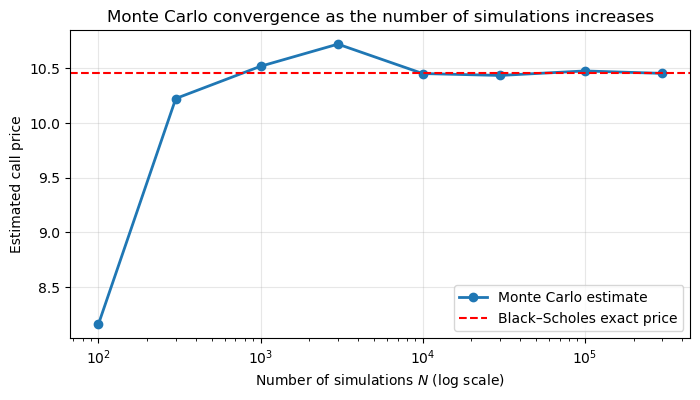

In [5]:
plt.figure(figsize=(8, 4))
plt.plot(sample_sizes, mc_estimates, marker='o', lw=2, label='Monte Carlo estimate')
plt.axhline(bs_exact, color='red', linestyle='--', label='Black–Scholes exact price')
plt.xscale('log')
plt.title('Monte Carlo convergence as the number of simulations increases')
plt.xlabel('Number of simulations $N$ (log scale)')
plt.ylabel('Estimated call price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### Interpretation

As $N$ increases, the Monte Carlo estimator becomes more stable and gets closer to the exact Black–Scholes price.

This is the basic convergence phenomenon behind simulation-based pricing.


## 9. Error and the rate $1/\sqrt{N}$

A fundamental fact about Monte Carlo is that its statistical error typically decreases like

$$
\frac{1}{\sqrt{N}}.
$$

This is both powerful and costly.
It means that:

- increasing $N$ improves accuracy,
- but to divide the error by 2, we need about **4 times more simulations**.

This slow convergence rate is one of the main practical limitations of Monte Carlo methods.


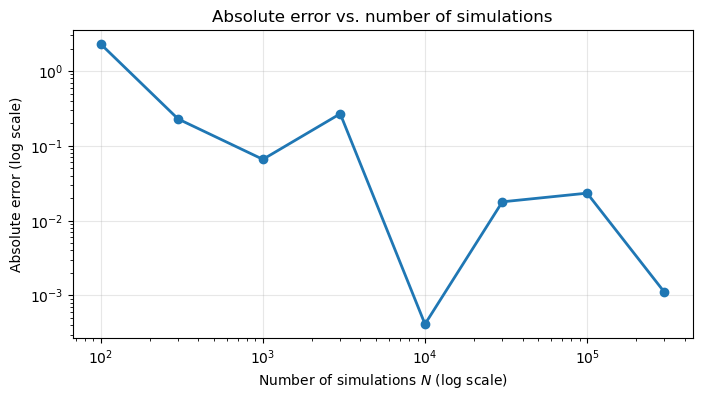

In [6]:
errors = [abs(est - bs_exact) for est in mc_estimates]

plt.figure(figsize=(8, 4))
plt.plot(sample_sizes, errors, marker='o', lw=2)
plt.xscale('log')
plt.yscale('log')
plt.title('Absolute error vs. number of simulations')
plt.xlabel('Number of simulations $N$ (log scale)')
plt.ylabel('Absolute error (log scale)')
plt.grid(True, alpha=0.3)
plt.show()


### Interpretation

On a log-log scale, the error generally decreases as the number of simulations increases.
The theoretical rate is roughly proportional to $N^{-1/2}$.


## 10. Pricing a European put by Monte Carlo

The procedure for a put option is exactly the same, except that the payoff becomes

$$
(K-S_T)^+.
$$

The estimator is

$$
\hat{P}_N = e^{-rT} \frac{1}{N} \sum_{i=1}^N \max(K-S_T^{(i)},0).
$$

We already implemented this estimator above.
The Monte Carlo philosophy is therefore the same for many different derivatives:

- simulate,
- compute the payoff,
- average,
- discount.


## 11. A compact reusable Monte Carlo function

It is often useful to write a compact function that returns both the call and put prices.


In [7]:
def mc_call_put_prices(S0, K, T, r, sigma, N, seed=None):
    if seed is not None:
        np.random.seed(seed)
    Z = np.random.randn(N)
    ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    call_payoffs = np.maximum(ST - K, 0)
    put_payoffs = np.maximum(K - ST, 0)
    call_price = np.exp(-r * T) * np.mean(call_payoffs)
    put_price = np.exp(-r * T) * np.mean(put_payoffs)
    return call_price, put_price

call_mc, put_mc = mc_call_put_prices(100, 100, 1.0, 0.05, 0.20, 200_000, seed=7)
print(f"Call MC price: {call_mc:.4f}")
print(f"Put MC price : {put_mc:.4f}")


Call MC price: 10.4271
Put MC price : 5.5639


## 12. Comparison table: exact formula vs. Monte Carlo

The next cell prints a small comparison between the exact Black–Scholes prices and the Monte Carlo approximations.


In [8]:
S0 = 100
K = 100
T = 1.0
r = 0.05
sigma = 0.20
N = 200_000

mc_call, mc_put = mc_call_put_prices(S0, K, T, r, sigma, N, seed=99)
bs_call = bs_call_price(S0, K, T, r, sigma)
bs_put = bs_put_price(S0, K, T, r, sigma)

print("European option pricing comparison")
print("-" * 40)
print(f"Black–Scholes call : {bs_call:.6f}")
print(f"Monte Carlo call   : {mc_call:.6f}")
print(f"Absolute error     : {abs(mc_call - bs_call):.6f}")
print()
print(f"Black–Scholes put  : {bs_put:.6f}")
print(f"Monte Carlo put    : {mc_put:.6f}")
print(f"Absolute error     : {abs(mc_put - bs_put):.6f}")


European option pricing comparison
----------------------------------------
Black–Scholes call : 10.450584
Monte Carlo call   : 10.446345
Absolute error     : 0.004238

Black–Scholes put  : 5.573526
Monte Carlo put    : 5.570286
Absolute error     : 0.003240


## 13. Advantages and limitations of Monte Carlo

### Advantages

- conceptually simple,
- flexible,
- works well in high-dimensional settings,
- adapts to many exotic payoffs.

### Limitations

- slow convergence,
- statistical noise,
- can require many simulations for high precision,
- may need variance reduction techniques to become more efficient.

In later steps, we will improve the basic Monte Carlo estimator using statistical tools.


## 14. Summary

### Main ideas to remember

- Under the risk-neutral Black–Scholes model,
  $$S_T = S_0 \exp\left(\left(r-\frac{1}{2}\sigma^2\right)T + \sigma\sqrt{T}Z\right).$$
- A European call price is the discounted expected payoff:
  $$C_0 = e^{-rT} \mathbb{E}[(S_T-K)^+].$$
- Monte Carlo approximates this expectation by simulation.
- The estimator is random because it depends on random samples.
- As the number of simulations increases, the estimator converges toward the true price.
- The typical error decreases like $1/\sqrt{N}$.


## 15. Exercises for the student

1. Why do we use the risk-free rate $r$ in the simulation of $S_T$?
2. Why is the Monte Carlo estimate random?
3. What are the four main steps of a Monte Carlo pricing algorithm?
4. Why does increasing the number of simulations improve the estimate?
5. If you want to divide the Monte Carlo error by 2, roughly how many more simulations do you need?
6. Why is Monte Carlo especially useful for complex derivatives?


## 16. What comes next?

Now that we have the basic Monte Carlo estimator, the next natural step is statistical analysis.

### **Notebook 6 — Why Monte Carlo Works: Law of Large Numbers, Central Limit Theorem, and Confidence Intervals**

In the next notebook, we can explain:

- why the Monte Carlo estimator converges,
- how to quantify its error,
- how to build a confidence interval,
- and why the accuracy improves like $1/\sqrt{N}$.
